# Phase 1, Experiment 1.1 — Baselines + Ridge/Lasso re-baseline

Re-establish a flat (single-stage) baseline on the new data layer with the full xP-included feature set. Two specific issues from the progress report are addressed here: the Ridge alpha grid was too narrow to show regularization actually biting (now wide log-spaced), and the cluster_id feature is run as an explicit ablation rather than left in by default.

Output is a results table comparing three naive baselines (global mean, trailing 3-GW average, xP passthrough) against Ridge and Lasso, plus a chosen feature configuration that subsequent experiments (1.2 hurdle, 1.3 Tweedie, 1.4 PCA) build on.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

sys.path.insert(0, str(Path.cwd()))
from src.config import PROCESSED_PATH, get_feature_group, get_splits

pd.set_option("display.float_format", "{:.4f}".format)
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv(PROCESSED_PATH)
train_mask, val_mask, test_mask = get_splits(df)

y_train = df.loc[train_mask, "total_points"].values
y_val = df.loc[val_mask, "total_points"].values
val_positions = df.loc[val_mask, "position"].values

print(f"shape: {df.shape}")
print(f"train: {train_mask.sum():,}  val: {val_mask.sum():,}  test: {test_mask.sum():,}  (test untouched in Phase 1)")

shape: (75075, 56)
train: 46,991  val: 23,825  test: 4,259  (test untouched in Phase 1)


## Val sanity check

Confirm the val set looks like what we expect before any modeling: target distribution, per-GW row counts (any sparse weeks?), per-position counts.

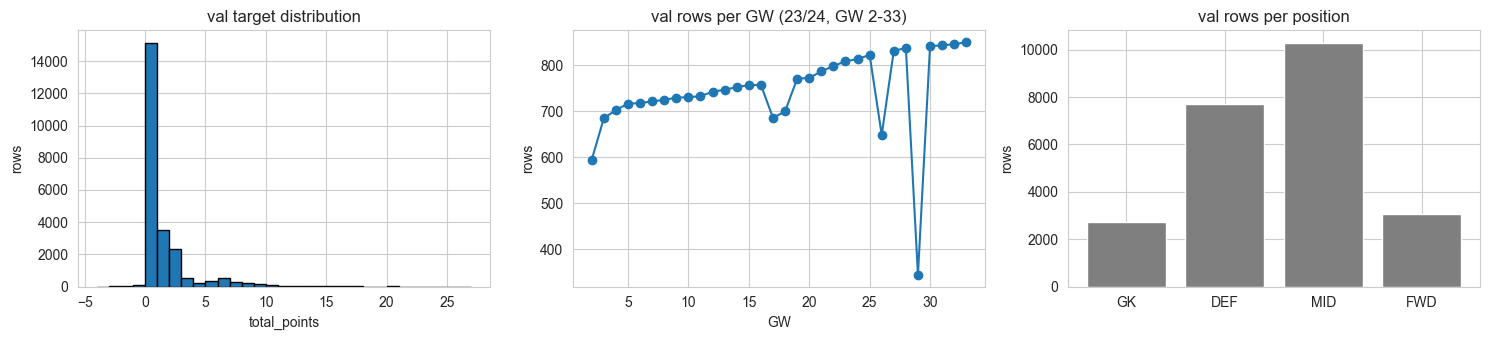

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

axes[0].hist(df.loc[val_mask, "total_points"], bins=range(-4, 28), edgecolor="black")
axes[0].set_title("val target distribution")
axes[0].set_xlabel("total_points")
axes[0].set_ylabel("rows")

per_gw = df.loc[val_mask].groupby("GW").size()
axes[1].plot(per_gw.index, per_gw.values, marker="o")
axes[1].set_title("val rows per GW (23/24, GW 2-33)")
axes[1].set_xlabel("GW")
axes[1].set_ylabel("rows")

per_pos = df.loc[val_mask, "position"].value_counts().reindex(["GK", "DEF", "MID", "FWD"])
axes[2].bar(per_pos.index, per_pos.values, color="tab:gray")
axes[2].set_title("val rows per position")
axes[2].set_ylabel("rows")

plt.tight_layout()
plt.show()

## Helpers

Three small utilities used throughout: column assembly from named feature groups, train-fit / val-transform standardization, and a metric reporter that includes per-position MAE for diagnostic attribution. Per-position is for diagnosis, not for model-splitting decisions — we don't have the feature breadth to justify position-specific models.

In [4]:
def feature_columns(groups):
    """Concatenate column lists from named feature groups."""
    cols = []
    for g in groups:
        cols.extend(get_feature_group(g))
    return cols


def build_X(df, mask, cols, scaler=None):
    """Standardize features. Fit scaler if not provided; otherwise transform with the given one."""
    X = df.loc[mask, cols].values
    if scaler is None:
        scaler = StandardScaler().fit(X)
    return scaler.transform(X), scaler


def evaluate(y_true, y_pred, positions=None):
    """R^2, MAE overall, and per-position MAE if positions provided."""
    out = {"r2": r2_score(y_true, y_pred), "mae": mean_absolute_error(y_true, y_pred)}
    if positions is not None:
        for pos in ["GK", "DEF", "MID", "FWD"]:
            m = positions == pos
            if m.sum():
                out[f"mae_{pos}"] = mean_absolute_error(y_true[m], y_pred[m])
    return out

## Naive baselines

Three reference points. Global mean is the floor (any model worse than this is broken). Trailing 3-GW average is the simplest non-trivial predictor — beating it convincingly is necessary, not sufficient. xP passthrough is FPL's own pre-kickoff predictor; this is the bar Phase 1 is actually trying to clear.

In [5]:
results = {}

y_pred = np.full_like(y_val, fill_value=y_train.mean(), dtype=float)
results["global mean"] = evaluate(y_val, y_pred, val_positions)

y_pred = df.loc[val_mask, "total_points_roll3"].values
results["trailing 3-GW avg"] = evaluate(y_val, y_pred, val_positions)

y_pred = df.loc[val_mask, "xP"].values
results["xP passthrough"] = evaluate(y_val, y_pred, val_positions)

pd.DataFrame(results).T

,r2,mae,mae_GK,mae_DEF,mae_MID,mae_FWD
global mean,-0.0102,1.5528,1.5135,1.5407,1.5454,1.6429
trailing 3-GW avg,0.1139,1.0405,0.6551,1.1193,1.0571,1.1300
xP passthrough,0.5169,0.8129,0.6629,0.8449,0.8271,0.8187


## Ridge alpha sweep

Wide log grid `[1e-4, 1e-2, 1, 100, 1e4, 1e6]` so we actually see regularization bite at the high end (R² should collapse toward the global-mean baseline as alpha → ∞). If the curve is still flat across this range, that's the finding — the feature set isn't overfitting in any L2 regime — and Lasso carries the regularization-vs-performance plot.

Run with and without `cluster_id` as the ablation called out in the plan. Phase 0 indicated `cluster_id` cost ~0.006 val R²; we're verifying that holds with the new data layer before locking it out.

In [6]:
GROUPS_BASE = ["BASE_PREKICKOFF", "POSITION", "XP", "ICT_BLOCK", "OTHER_LAGS"]
RIDGE_ALPHAS = [1e-4, 1e-2, 1, 100, 1e4, 1e6]


def sweep_alphas(model_cls, alphas, groups):
    cols = feature_columns(groups)
    X_tr, scaler = build_X(df, train_mask, cols)
    X_va, _ = build_X(df, val_mask, cols, scaler=scaler)
    rows = []
    for a in alphas:
        kw = {"max_iter": 20000} if model_cls is Lasso else {}
        m = model_cls(alpha=a, **kw).fit(X_tr, y_train)
        pred = m.predict(X_va)
        rows.append({"alpha": a, **evaluate(y_val, pred, val_positions)})
    return pd.DataFrame(rows), cols


ridge_base, _ = sweep_alphas(Ridge, RIDGE_ALPHAS, GROUPS_BASE)
ridge_cluster, _ = sweep_alphas(Ridge, RIDGE_ALPHAS, GROUPS_BASE + ["CLUSTER"])

print("Ridge — without cluster")
print(ridge_base.to_string(index=False))
print("\nRidge — with cluster")
print(ridge_cluster.to_string(index=False))

Ridge — without cluster
       alpha     r2    mae  mae_GK  mae_DEF  mae_MID  mae_FWD
      0.0001 0.5989 0.8275  0.6787   0.8451   0.8370   0.8837
      0.0100 0.5989 0.8275  0.6787   0.8451   0.8370   0.8837
      1.0000 0.5989 0.8275  0.6787   0.8451   0.8370   0.8834
    100.0000 0.5985 0.8263  0.6768   0.8444   0.8356   0.8826
  10000.0000 0.5361 0.8418  0.6346   0.8788   0.8511   0.9024
1000000.0000 0.1895 1.2874  1.1600   1.3260   1.2711   1.3585

Ridge — with cluster
       alpha     r2    mae  mae_GK  mae_DEF  mae_MID  mae_FWD
      0.0001 0.5983 0.8323  0.6882   0.8494   0.8434   0.8805
      0.0100 0.5983 0.8323  0.6882   0.8494   0.8434   0.8804
      1.0000 0.5983 0.8323  0.6881   0.8494   0.8434   0.8802
    100.0000 0.5979 0.8311  0.6860   0.8488   0.8420   0.8792
  10000.0000 0.5358 0.8433  0.6386   0.8817   0.8528   0.8976
1000000.0000 0.1904 1.2846  1.1529   1.3254   1.2684   1.3538


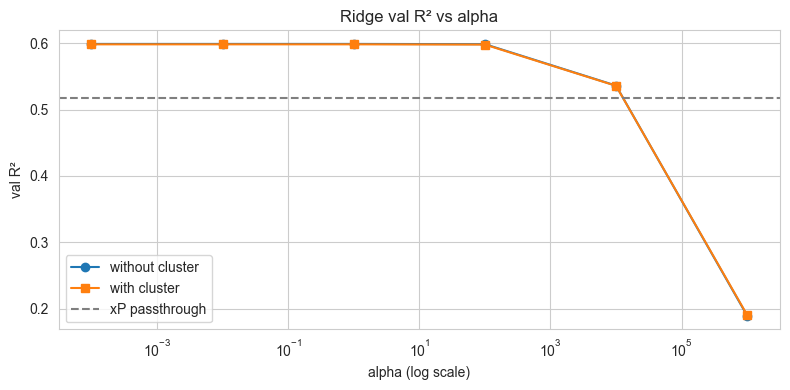

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(ridge_base["alpha"], ridge_base["r2"], marker="o", label="without cluster")
ax.semilogx(ridge_cluster["alpha"], ridge_cluster["r2"], marker="s", label="with cluster")
ax.axhline(results["xP passthrough"]["r2"], linestyle="--", color="tab:gray", label="xP passthrough")
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("val R²")
ax.set_title("Ridge val R² vs alpha")
ax.legend()
plt.tight_layout()
plt.show()

## Lasso alpha sweep

Same ablation pattern. Lasso grid `[1e-4, 1e-3, 1e-2, 1e-1, 1, 10]` — at the low end behaves like OLS, at the high end zeros out all features and degrades to the mean. This should produce a meaningfully shaped curve regardless of whether Ridge does.

In [8]:
LASSO_ALPHAS = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]

lasso_base, lasso_cols = sweep_alphas(Lasso, LASSO_ALPHAS, GROUPS_BASE)
lasso_cluster, _ = sweep_alphas(Lasso, LASSO_ALPHAS, GROUPS_BASE + ["CLUSTER"])

print("Lasso — without cluster")
print(lasso_base.to_string(index=False))
print("\nLasso — with cluster")
print(lasso_cluster.to_string(index=False))

Lasso — without cluster
  alpha      r2    mae  mae_GK  mae_DEF  mae_MID  mae_FWD
 0.0001  0.5989 0.8273  0.6785   0.8449   0.8370   0.8828
 0.0010  0.5989 0.8264  0.6775   0.8433   0.8367   0.8817
 0.0100  0.5970 0.8238  0.6798   0.8425   0.8330   0.8745
 0.1000  0.5606 0.8514  0.7020   0.8851   0.8648   0.8552
 1.0000  0.3605 1.1488  1.0494   1.1758   1.1403   1.1976
10.0000 -0.0102 1.5528  1.5135   1.5407   1.5454   1.6429

Lasso — with cluster
  alpha      r2    mae  mae_GK  mae_DEF  mae_MID  mae_FWD
 0.0001  0.5983 0.8320  0.6879   0.8493   0.8433   0.8794
 0.0010  0.5983 0.8308  0.6858   0.8488   0.8418   0.8781
 0.0100  0.5967 0.8255  0.6778   0.8464   0.8351   0.8721
 0.1000  0.5606 0.8514  0.7020   0.8851   0.8648   0.8552
 1.0000  0.3605 1.1488  1.0494   1.1758   1.1403   1.1976
10.0000 -0.0102 1.5528  1.5135   1.5407   1.5454   1.6429


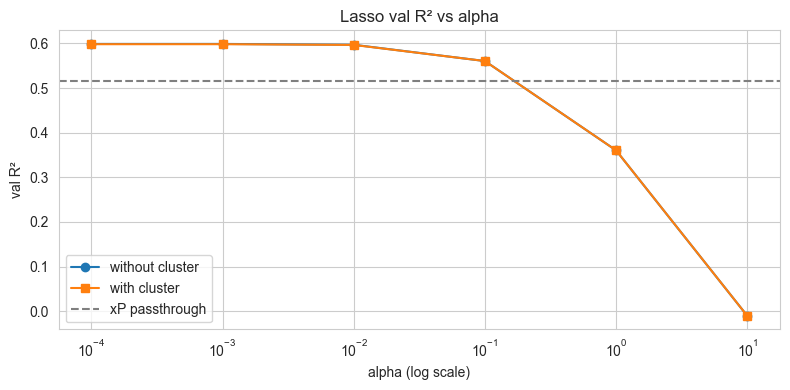

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(lasso_base["alpha"], lasso_base["r2"], marker="o", label="without cluster")
ax.semilogx(lasso_cluster["alpha"], lasso_cluster["r2"], marker="s", label="with cluster")
ax.axhline(results["xP passthrough"]["r2"], linestyle="--", color="tab:gray", label="xP passthrough")
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("val R²")
ax.set_title("Lasso val R² vs alpha")
ax.legend()
plt.tight_layout()
plt.show()

## Lasso coefficients at best alpha

What features survive at the best Lasso alpha? Useful for sanity-checking what the linear model is leaning on (xP and recent-form lags should dominate; if obscure transfer-flow features are large, that's a red flag).

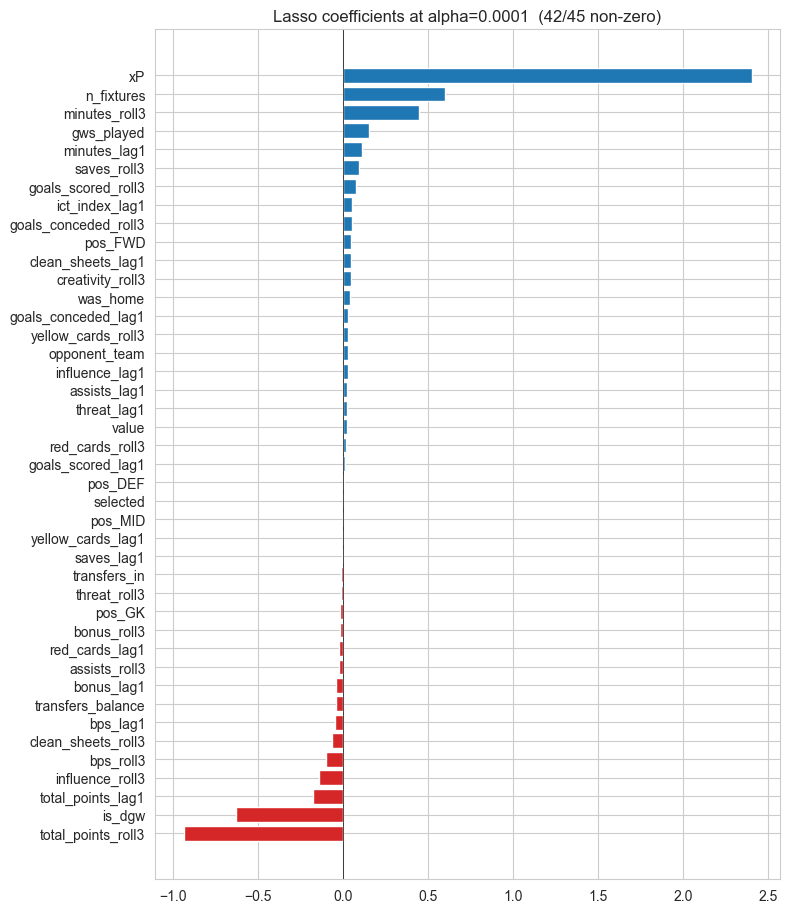

In [10]:
best_lasso_alpha = lasso_base.loc[lasso_base["r2"].idxmax(), "alpha"]

cols = feature_columns(GROUPS_BASE)
X_tr, scaler = build_X(df, train_mask, cols)
best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=20000).fit(X_tr, y_train)

coef_df = pd.DataFrame({"feature": cols, "coef": best_lasso.coef_})
nonzero = coef_df[coef_df["coef"].abs() > 1e-6].sort_values("coef")

fig, ax = plt.subplots(figsize=(8, max(4, len(nonzero) * 0.22)))
colors = ["tab:red" if c < 0 else "tab:blue" for c in nonzero["coef"]]
ax.barh(nonzero["feature"], nonzero["coef"], color=colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_title(f"Lasso coefficients at alpha={best_lasso_alpha:g}  ({len(nonzero)}/{len(cols)} non-zero)")
plt.tight_layout()
plt.show()

## Combined results table

Best Ridge and best Lasso (no-cluster configs) added to the baseline table. This is the 1.1 contribution to the Phase 1 deliverable.

In [11]:
best_ridge_row = ridge_base.loc[ridge_base["r2"].idxmax()]
best_lasso_row = lasso_base.loc[lasso_base["r2"].idxmax()]

results[f"Ridge (alpha={best_ridge_row['alpha']:g})"] = {
    k: v for k, v in best_ridge_row.items() if k != "alpha"
}
results[f"Lasso (alpha={best_lasso_row['alpha']:g})"] = {
    k: v for k, v in best_lasso_row.items() if k != "alpha"
}

ridge_delta = ridge_cluster["r2"].max() - ridge_base["r2"].max()
lasso_delta = lasso_cluster["r2"].max() - lasso_base["r2"].max()
print(f"Cluster ablation Δ val R²:  Ridge {ridge_delta:+.4f}   Lasso {lasso_delta:+.4f}")
print("(negative = cluster hurts; consistent with Phase 0 finding -> drop CLUSTER going forward)\n")

pd.DataFrame(results).T

Cluster ablation Δ val R²:  Ridge -0.0006   Lasso -0.0006
(negative = cluster hurts; consistent with Phase 0 finding -> drop CLUSTER going forward)



,r2,mae,mae_GK,mae_DEF,mae_MID,mae_FWD
global mean,-0.0102,1.5528,1.5135,1.5407,1.5454,1.6429
trailing 3-GW avg,0.1139,1.0405,0.6551,1.1193,1.0571,1.1300
xP passthrough,0.5169,0.8129,0.6629,0.8449,0.8271,0.8187
Ridge (alpha=1),0.5989,0.8275,0.6787,0.8451,0.8370,0.8834
Lasso (alpha=0.0001),0.5989,0.8273,0.6785,0.8449,0.8370,0.8828


## Residual diagnostics for the best linear model

Use best Ridge (no cluster) — pick Ridge over Lasso here unless Lasso clearly wins on val R²; their predictions are usually similar but Ridge keeps all features non-zero which gives a richer residuals-vs-features picture. Two views: residuals vs prediction (looking for heteroscedasticity / non-linearity) and residuals by position (looking for systematic per-position bias that would inform Phase 3 error analysis).

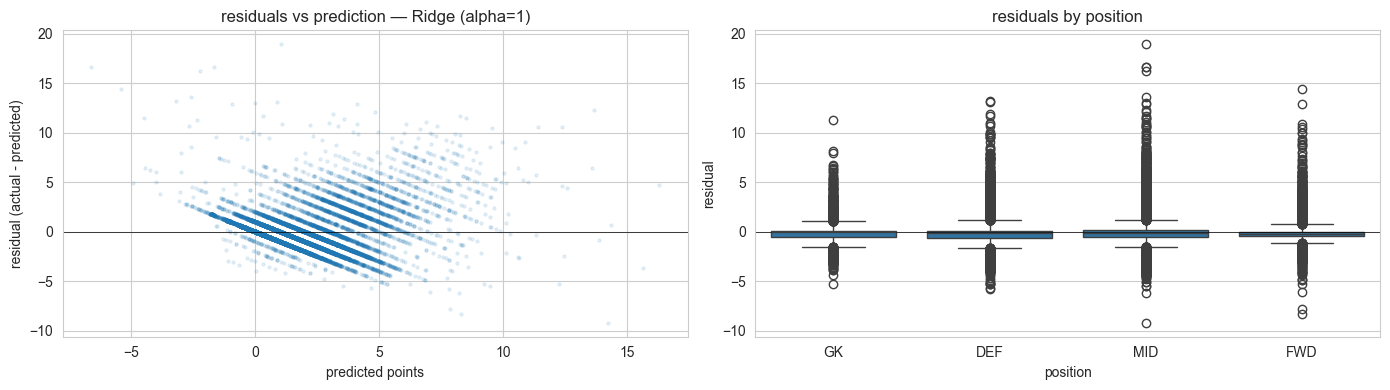

In [12]:
best_ridge_alpha = best_ridge_row["alpha"]
cols = feature_columns(GROUPS_BASE)
X_tr, scaler = build_X(df, train_mask, cols)
X_va, _ = build_X(df, val_mask, cols, scaler=scaler)
best_ridge = Ridge(alpha=best_ridge_alpha).fit(X_tr, y_train)

val_pred = best_ridge.predict(X_va)
val_resid = y_val - val_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(val_pred, val_resid, alpha=0.1, s=5)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_xlabel("predicted points")
axes[0].set_ylabel("residual (actual - predicted)")
axes[0].set_title(f"residuals vs prediction — Ridge (alpha={best_ridge_alpha:g})")

resid_df = pd.DataFrame({"position": val_positions, "residual": val_resid})
sns.boxplot(data=resid_df, x="position", y="residual", order=["GK", "DEF", "MID", "FWD"], ax=axes[1])
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("residuals by position")

plt.tight_layout()
plt.show()

## Decision: flat baseline for downstream experiments

The configuration carried forward into 1.2 / 1.3 / 1.4 is `BASE_PREKICKOFF + POSITION + XP + ICT_BLOCK + OTHER_LAGS` (no CLUSTER), with standardization fit on train. Whether Ridge or Lasso is the specific "flat baseline" model depends on which wins above; record it explicitly and move on.

Open questions to interpret with the user before building 1.2:

- Does any model meaningfully beat xP passthrough? If yes, by how much, and is it concentrated in one position or distributed? If xP passthrough is hard to beat with linear models, that strongly motivates the hurdle / Tweedie / MLP work — they need to earn the spot xP holds.
- Did the wide Ridge alpha sweep show meaningful curvature, or is it still flat? The latter is fine to report as a finding.
- Are residuals symmetric and roughly mean-zero per position? Asymmetric residuals at one position would indicate the linear model is systematically wrong about that group — useful Phase 3 fodder.